# CREDIT CARD FRAUD DETECTION (SMOTE)


Before SMOTE Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.87      0.62      0.73       136

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



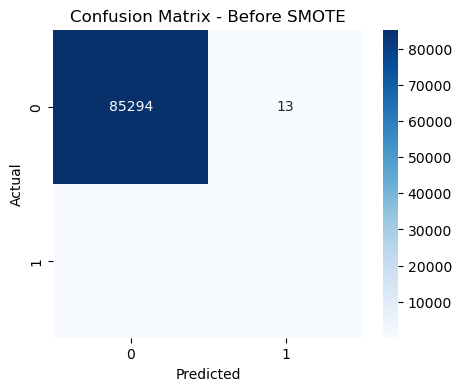

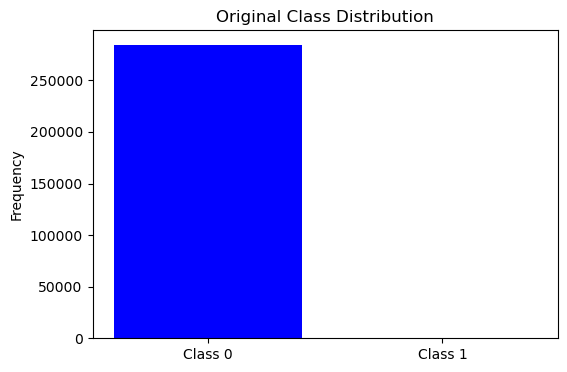

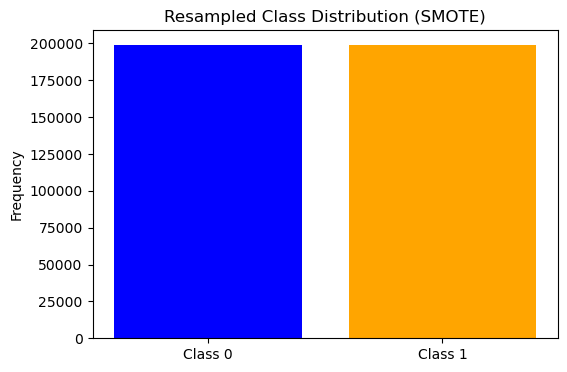


After SMOTE Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     85307
           1       0.05      0.93      0.10       136

    accuracy                           0.97     85443
   macro avg       0.53      0.95      0.54     85443
weighted avg       1.00      0.97      0.99     85443



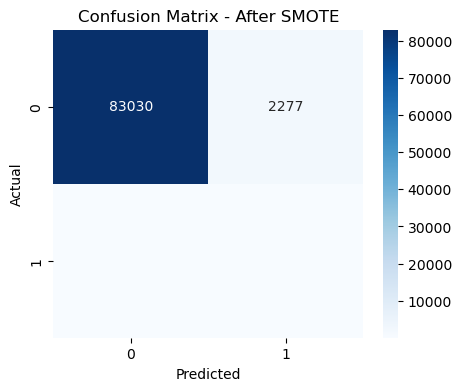

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv('creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Evaluation function
def evaluate_model(model, X_test, y_test, label=""):
    y_pred = model.predict(X_test)
    print(f"\n{label} Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Model before SMOTE
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
evaluate_model(model, X_test_scaled, y_test, label="Before SMOTE")

# Class distribution before SMOTE
plt.figure(figsize=(6, 4))
plt.bar(['Class 0', 'Class 1'], [Counter(y)[0], Counter(y)[1]], color=['blue', 'orange'])
plt.title('Original Class Distribution')
plt.ylabel('Frequency')
plt.show()

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Class distribution after SMOTE
plt.figure(figsize=(6, 4))
plt.bar(['Class 0', 'Class 1'], [Counter(y_train_sm)[0], Counter(y_train_sm)[1]], color=['blue', 'orange'])
plt.title('Resampled Class Distribution (SMOTE)')
plt.ylabel('Frequency')
plt.show()

# Model after SMOTE
model.fit(X_train_sm, y_train_sm)
evaluate_model(model, X_test_scaled, y_test, label="After SMOTE")


# MNIST DATASET EDA

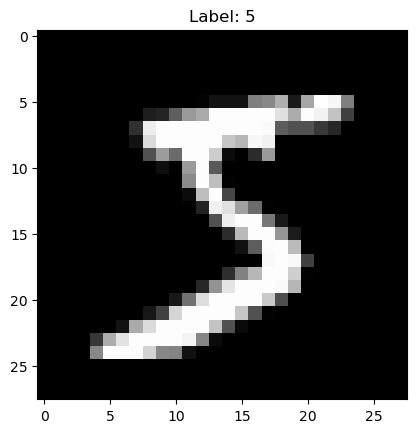

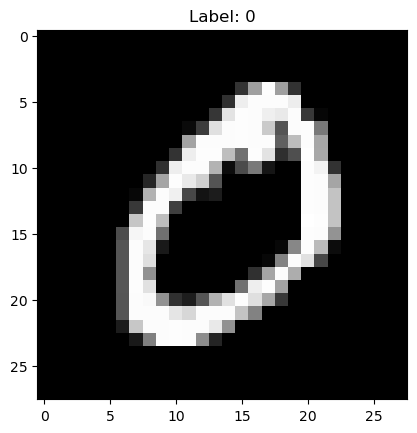

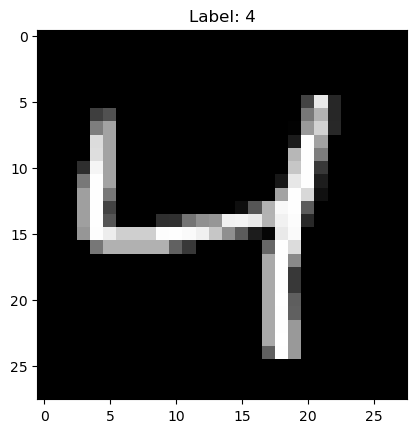

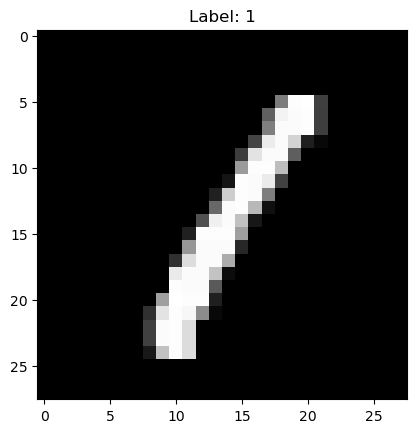

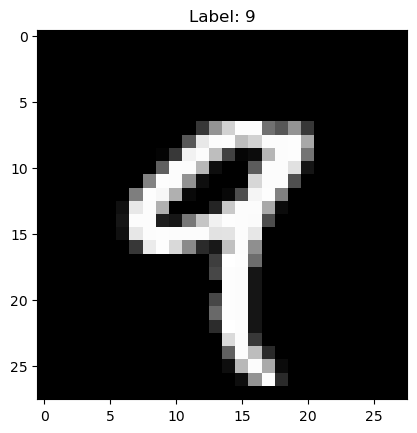

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Class distribution: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


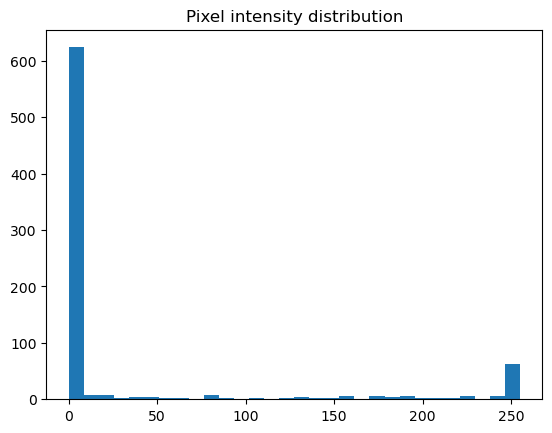

0 0


In [2]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 1. Display some images
for i in range(5):
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.show()

# 2. Shape of data
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# 3. Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

# 4. Pixel intensity distribution
plt.hist(x_train[0].ravel(), bins=30)
plt.title("Pixel intensity distribution")
plt.show()

# 5. Check for nulls
print(np.isnan(x_train).sum(), np.isnan(y_train).sum())
